# E3SM Diagnostics: Monthly Time Series Comparison

This notebook generates area-weighted global (or land-masked) monthly time series comparisons for the 4 E3SM simulations (`BruteForce`, `JRA55_FOSIRL`, `4DEnVar_branch`, `4DEnVar_hybrid`).

It loads the monthly NetCDF files directly from post-processed history directories, handles both single-member and multi-member directory configurations, and plots them with sleek, premium diagnostics styling.

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path
from IPython.display import Image, display

# Set project root path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from workflows.e3sm_timeseries_compare import load_simulation_timeseries, plot_timeseries_comparison

## Configuration and Execution Block
Specify your configurations and execute this cell to generate and display the time series comparisons.


--- Processing variable: TREFHT ---


Success! Saved time series comparison to: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D/e3sm_timeseries_TREFHT.png


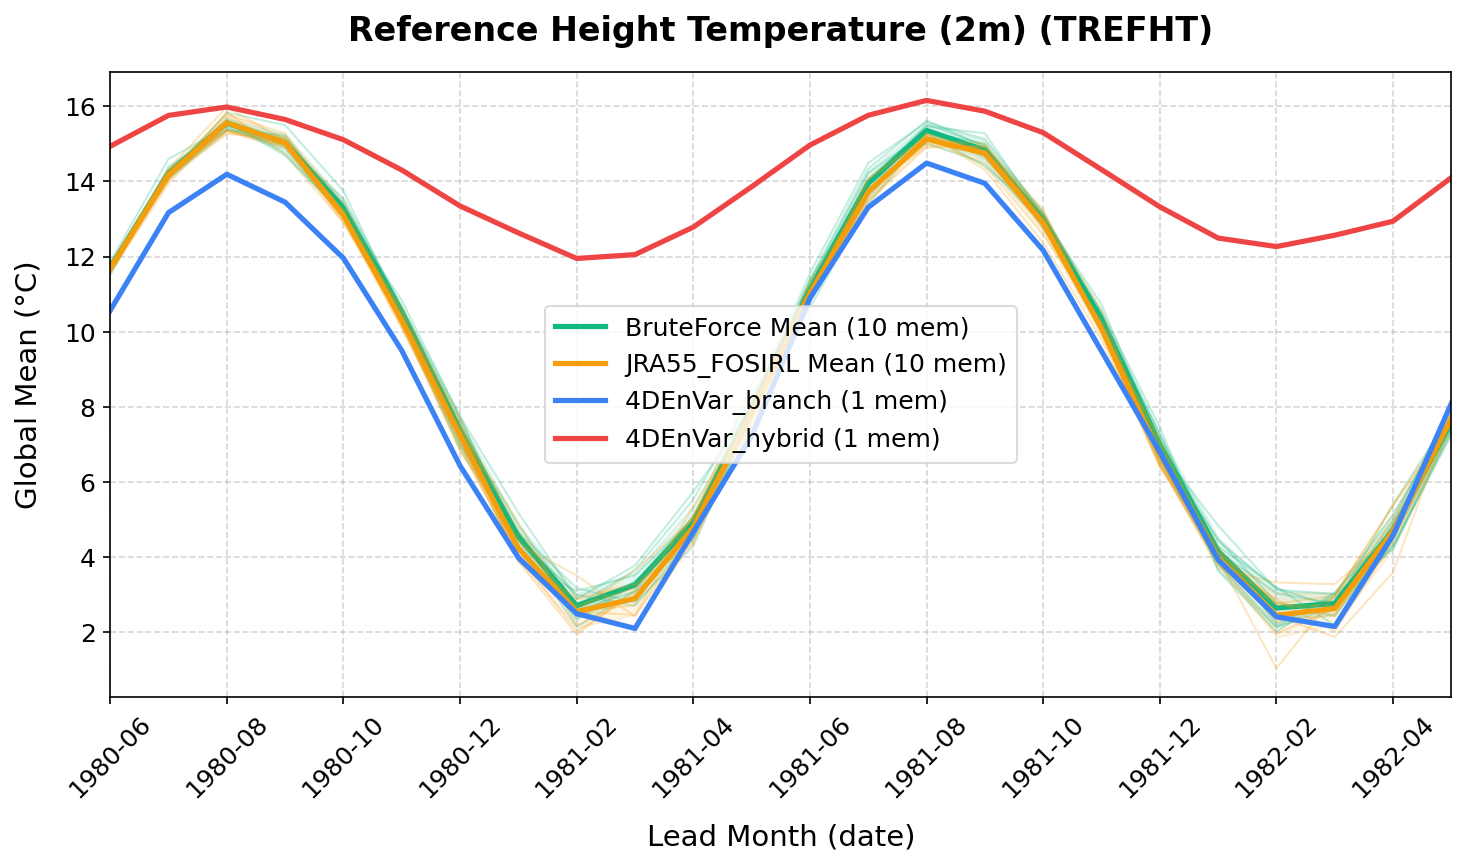


--- Processing variable: PRECT ---


Success! Saved time series comparison to: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D/e3sm_timeseries_PRECT.png


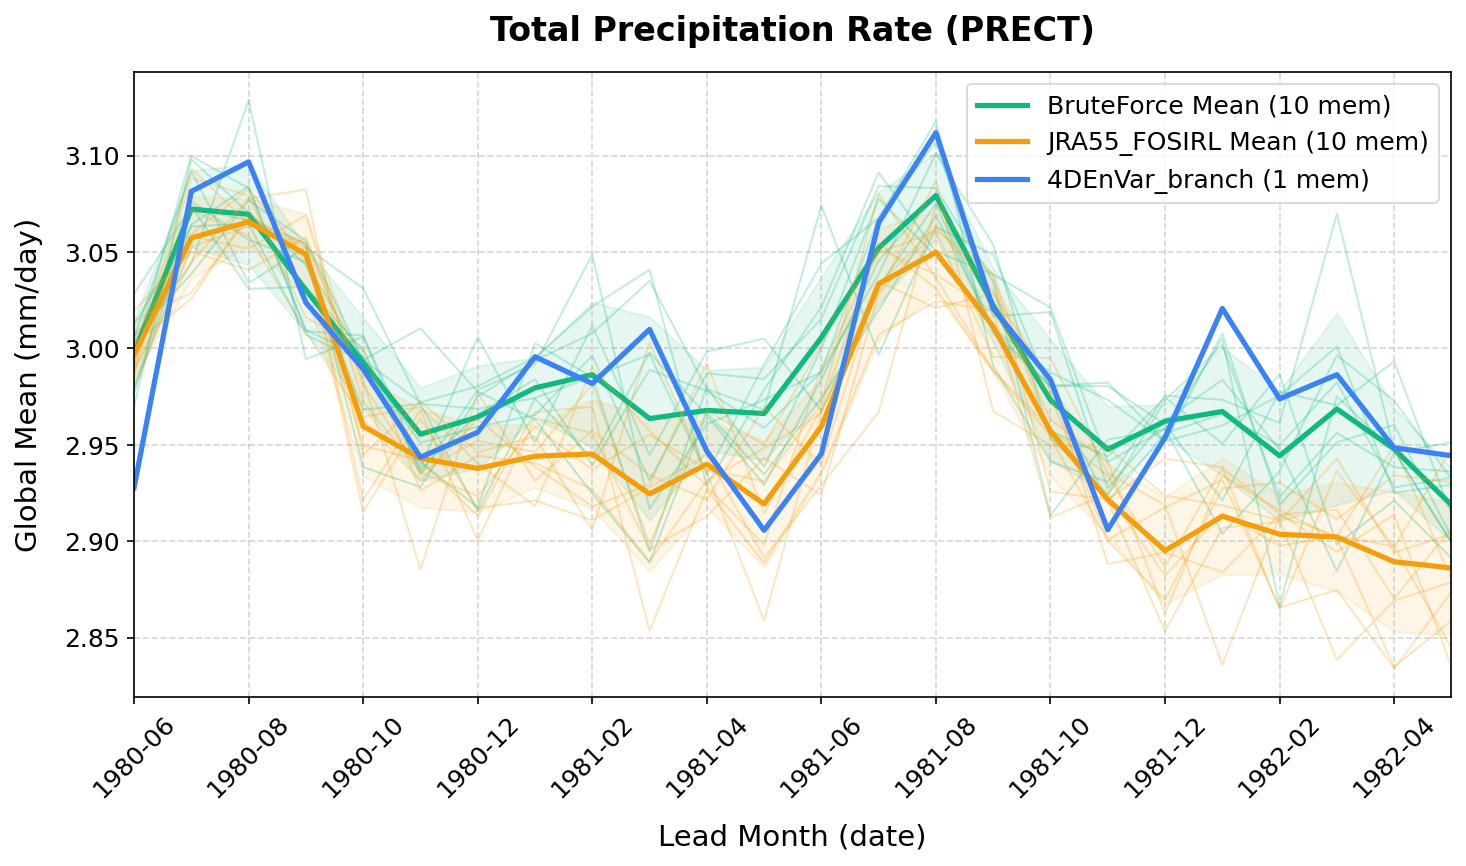


--- Processing variable: PSL ---


Success! Saved time series comparison to: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D/e3sm_timeseries_PSL.png


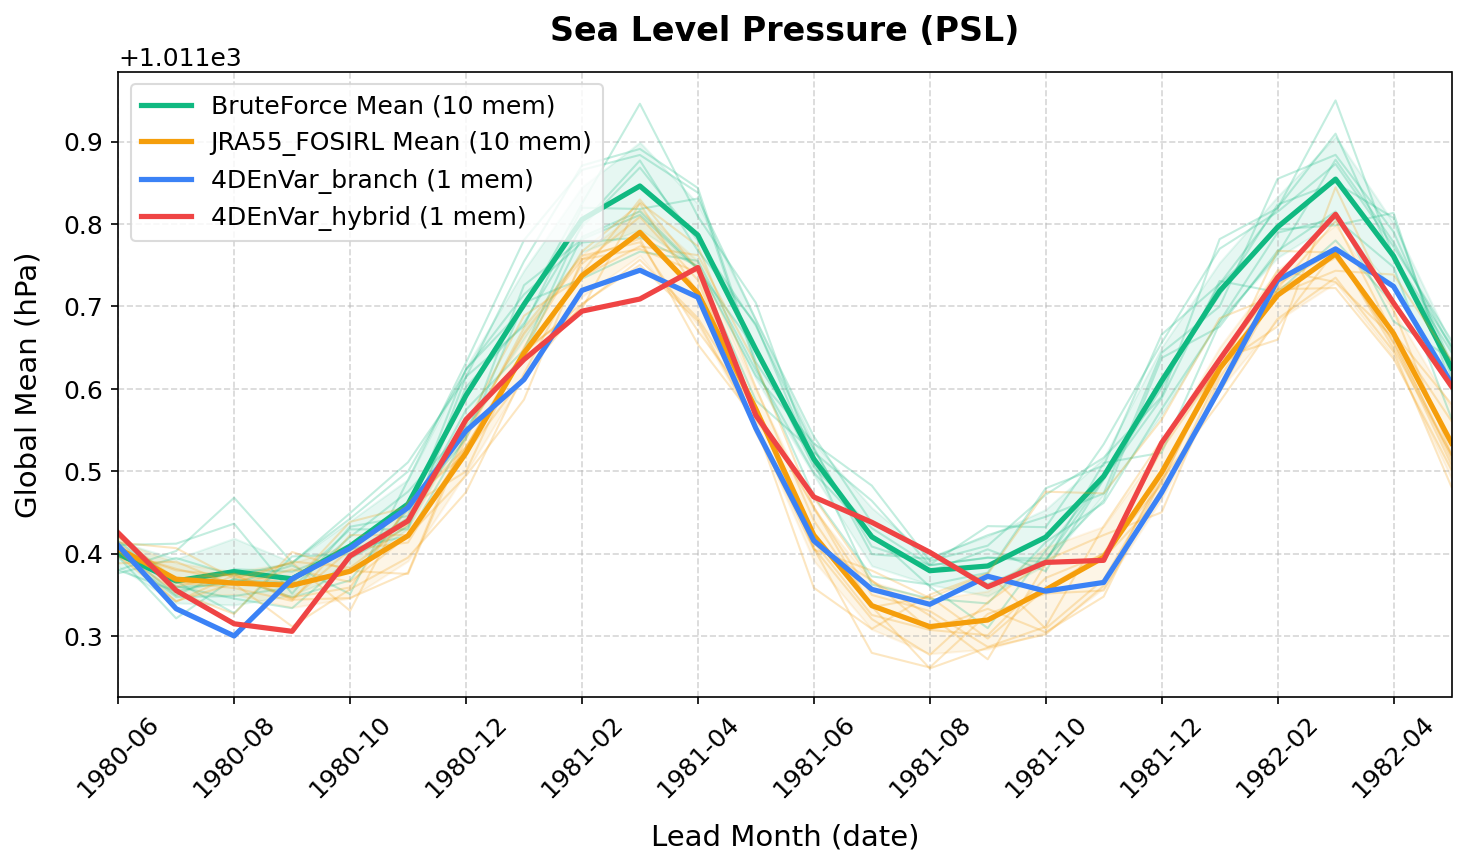


--- Processing variable: SWCF ---


Success! Saved time series comparison to: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D/e3sm_timeseries_SWCF.png


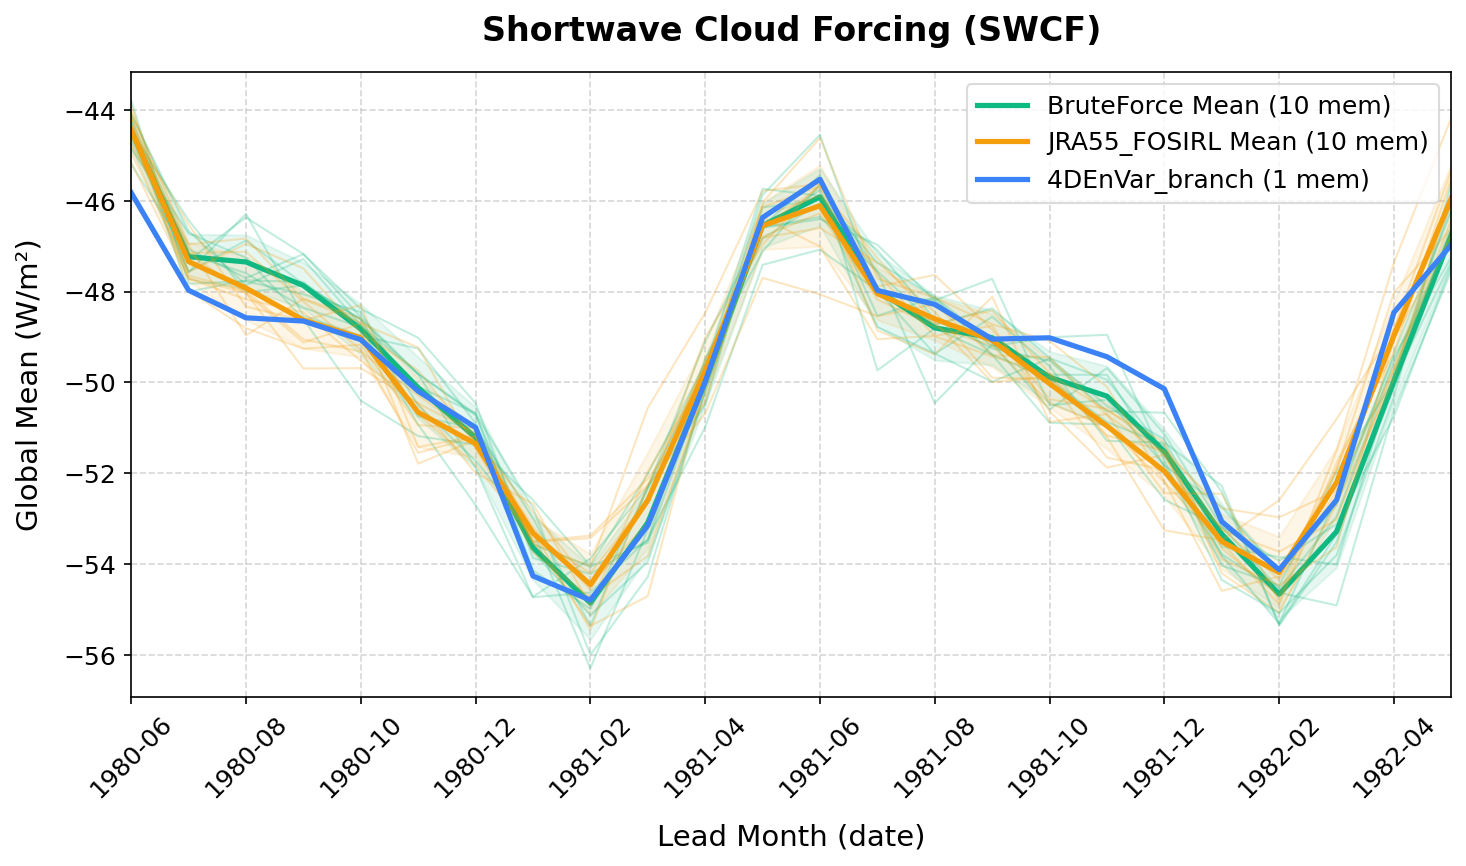


--- Processing variable: LWCF ---


Success! Saved time series comparison to: /global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D/e3sm_timeseries_LWCF.png


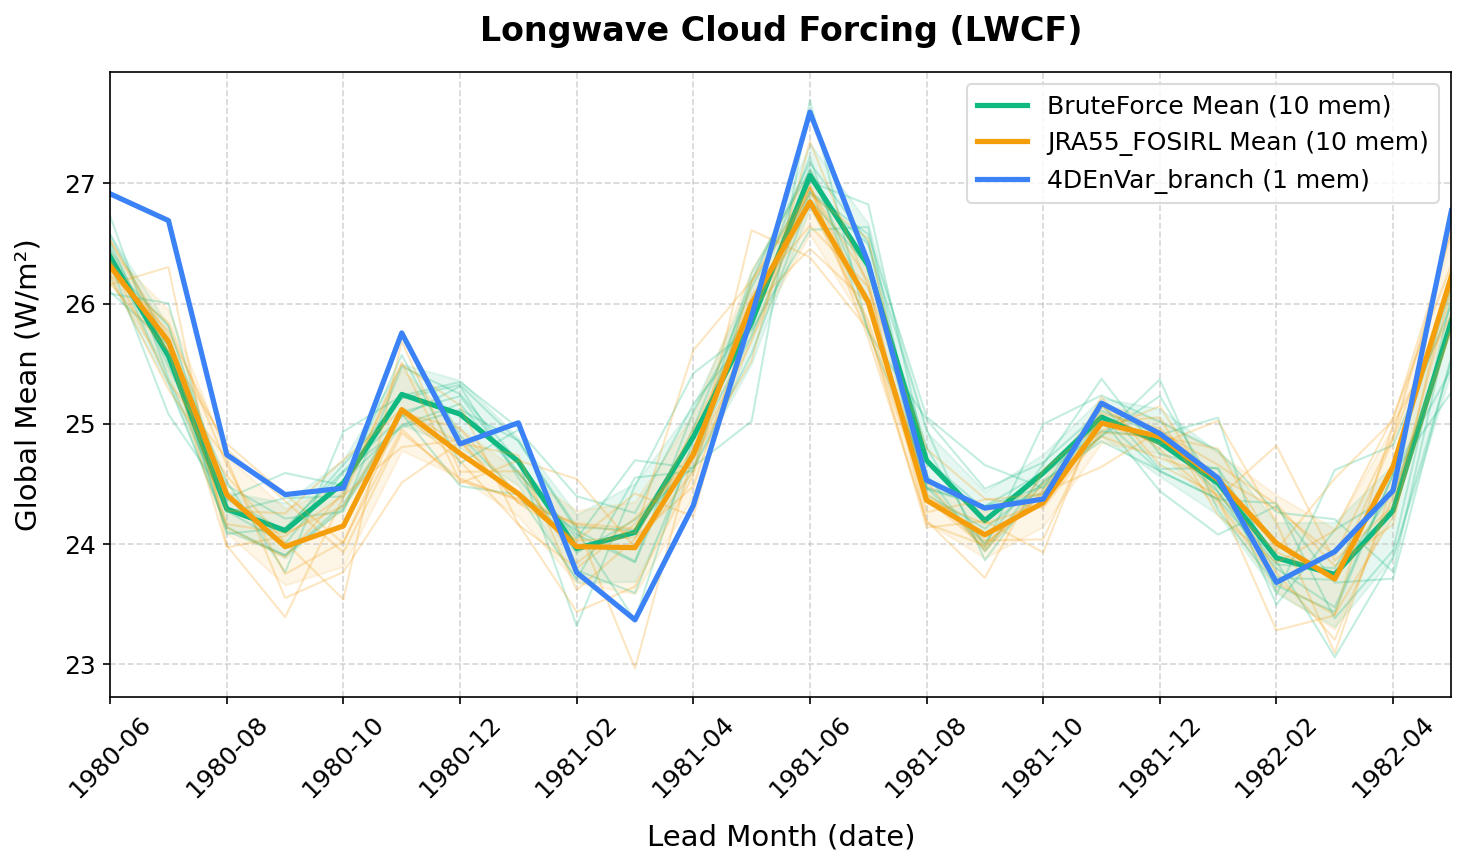

In [2]:
# ==========================================================
# INPUT PARAMETERS & SETUP
# ==========================================================
base_dir = "/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D"
output_dir = "/global/cfs/cdirs/e3sm/www/zhan391/E3SMv3_S2D"

# Dictionary mapping simulation labels to their subdirectories. 
simulations = {
    'BruteForce': {'run_name': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce_1980050100', 'ens': 10},
    'JRA55_FOSIRL': {'run_name': 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100', 'ens': 10},
    '4DEnVar_branch': {'run_name': 'test_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVar_branch', 'ens': 1},
    '4DEnVar_hybrid': {'run_name': 'test_WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVar_hybrid', 'ens': 1},
}

# Variables to compare
variables = ['TREFHT', 'PRECT', 'PSL', 'SWCF', 'LWCF']

init_tag = "1980050100"
nlead = 24          # Number of lead months to plot
fontz = 14          # Font size scaling
figsize = [10, 6]   # Figure aspect ratio

# ==========================================================
# GENERATE & DISPLAY TIME SERIES COMPARISONS
# ==========================================================
for variable in variables:
    print(f"\n--- Processing variable: {variable} ---")
    data = load_simulation_timeseries(base_dir, simulations, variable, init_tag=init_tag, nlead=nlead)
    plot_timeseries_comparison(data, variable, output_dir, figsize=figsize, fontz=fontz)
    
    # Display inline
    img_path = os.path.join(output_dir, f"e3sm_timeseries_{variable}.png")
    if os.path.exists(img_path):
        display(Image(filename=img_path, width=850))
    else:
        print(f"Warning: Figure not found at {img_path}\n")